<a href="https://colab.research.google.com/github/Zahra2351373/Bold-Dataset/blob/Master/EDA_BoldDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup and Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


**`Load and Initial Data Inspection`**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load the full BOLD dataset
df = pd.read_csv('/content/drive/MyDrive/bold_dataset.csv', low_memory=False)

print("=== BOLD Dataset Overview ===")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Display first few rows and basic info
print("\nFirst 5 rows:")
print(df.head())

print(f"\nColumn names ({len(df.columns)} total):")
print(df.columns.tolist()[:20], "... (showing first 20)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== BOLD Dataset Overview ===
Dataset shape: 49,093 rows × 142 columns
Memory usage: 87.5 MB

First 5 rows:
   unique_subject_id  unique_hospital_admission_id  unique_icustay_id  \
0                  0                             0                  0   
1                  1                             1                  1   
2                  2                             2                  2   
3                  3                             3                  3   
4                  4                             4                  4   

  subject_id  hospital_admission_id  icustay_id source_db  hospitalid  \
0  002-10050                 183274      211144      eicu          71   
1   002-1007                 178462      204935      eicu          71   
2  002-10187                 150828      169525      eicu          73   
3  002-10306                 198

**Demographics and Patient Characteristics**

In [ ]:
print("=== TABLE 1: PATIENT DEMOGRAPHICS AND CHARACTERISTICS ===")

# Initialize results dictionary for Table 1
table1_results = {}

# 1. Total Sample Size
table1_results['Total Patients'] = f"{len(df):,}"

# 2. Age Statistics
age_stats = df['admission_age'].describe()
table1_results['Age, years'] = {
    'Mean (SD)': f"{age_stats['mean']:.1f} ({age_stats['std']:.1f})",
    'Median [IQR]': f"{age_stats['50%']:.0f} [{age_stats['25%']:.0f}-{age_stats['75%']:.0f}]",
    'Range': f"{age_stats['min']:.0f}-{age_stats['max']:.0f}",
    'Missing': f"{df['admission_age'].isna().sum():,} ({df['admission_age'].isna().sum()/len(df)*100:.1f}%)"
}

# 3. Sex Distribution
sex_counts = df['sex_female'].value_counts()
table1_results['Sex'] = {
    'Female': f"{sex_counts.get(1, 0):,} ({sex_counts.get(1, 0)/len(df)*100:.1f}%)",
    'Male': f"{sex_counts.get(0, 0):,} ({sex_counts.get(0, 0)/len(df)*100:.1f}%)",
    'Missing': f"{df['sex_female'].isna().sum():,} ({df['sex_female'].isna().sum()/len(df)*100:.1f}%)"
}

# 4. Race/Ethnicity Distribution
race_counts = df['race_ethnicity'].value_counts()
race_missing = df['race_ethnicity'].isna().sum()
table1_results['Race/Ethnicity'] = {}
for race, count in race_counts.items():
    table1_results['Race/Ethnicity'][race] = f"{count:,} ({count/len(df)*100:.1f}%)"
table1_results['Race/Ethnicity']['Missing/Unknown'] = f"{race_missing:,} ({race_missing/len(df)*100:.1f}%)"

# 5. Source Database Distribution
source_counts = df['source_db'].value_counts()
table1_results['Source Database'] = {}
for source, count in source_counts.items():
    table1_results['Source Database'][source] = f"{count:,} ({count/len(df)*100:.1f}%)"

# Print Table 1
print("\n" + "="*60)
print("TABLE 1: PATIENT DEMOGRAPHICS AND CHARACTERISTICS")
print("="*60)
for category, values in table1_results.items():
    print(f"\n{category}:")
    if isinstance(values, dict):
        for subcategory, value in values.items():
            print(f"  {subcategory}: {value}")
    else:
        print(f"  {values}")

=== TABLE 1: PATIENT DEMOGRAPHICS AND CHARACTERISTICS ===

TABLE 1: PATIENT DEMOGRAPHICS AND CHARACTERISTICS

Total Patients:
  49,093

Age, years:
  Mean (SD): 64.4 (15.8)
  Median [IQR]: 66 [55-76]
  Range: 14-90
  Missing: 2 (0.0%)

Sex:
  Female: 21,433 (43.7%)
  Male: 27,660 (56.3%)
  Missing: 0 (0.0%)

Race/Ethnicity:
  White: 37,380 (76.1%)
  Black: 4,785 (9.7%)
  Unknown: 3,562 (7.3%)
  Hispanic OR Latino: 2,116 (4.3%)
  Asian: 858 (1.7%)
  American Indian / Alaska Native: 380 (0.8%)
  Native Hawaiian / Pacific Islander: 9 (0.0%)
  More Than One Race: 3 (0.0%)
  Missing/Unknown: 0 (0.0%)

Source Database:
  eicu: 43,438 (88.5%)
  mimic_iv: 4,915 (10.0%)
  mimic_iii: 740 (1.5%)


**Clinical Characteristics**




In [ ]:
print("\n=== TABLE 1 CONTINUED: CLINICAL CHARACTERISTICS ===")

# 6. BMI Statistics
bmi_stats = df['BMI_admission'].describe()
table1_results['BMI, kg/m²'] = {
    'Mean (SD)': f"{bmi_stats['mean']:.1f} ({bmi_stats['std']:.1f})",
    'Median [IQR]': f"{bmi_stats['50%']:.1f} [{bmi_stats['25%']:.1f}-{bmi_stats['75%']:.1f}]",
    'Missing': f"{df['BMI_admission'].isna().sum():,} ({df['BMI_admission'].isna().sum()/len(df)*100:.1f}%)"
}

# 7. Hospital Characteristics
bed_counts = df['numbedscategory'].value_counts()
table1_results['Hospital Bed Size'] = {}
for beds, count in bed_counts.items():
    table1_results['Hospital Bed Size'][beds] = f"{count:,} ({count/len(df)*100:.1f}%)"

teaching_counts = df['teachingstatus'].value_counts()
table1_results['Teaching Hospital'] = {
    'Yes': f"{teaching_counts.get(1, 0):,} ({teaching_counts.get(1, 0)/len(df)*100:.1f}%)",
    'No': f"{teaching_counts.get(0, 0):,} ({teaching_counts.get(0, 0)/len(df)*100:.1f}%)"
}

region_counts = df['region'].value_counts()
table1_results['US Region'] = {}
for region, count in region_counts.items():
    table1_results['US Region'][region] = f"{count:,} ({count/len(df)*100:.1f}%)"

# 8. Length of Stay
los_hospital_stats = df['los_hospital'].describe()
los_icu_stats = df['los_ICU'].describe()

table1_results['Length of Stay, days'] = {
    'Hospital - Mean (SD)': f"{los_hospital_stats['mean']:.1f} ({los_hospital_stats['std']:.1f})",
    'Hospital - Median [IQR]': f"{los_hospital_stats['50%']:.1f} [{los_hospital_stats['25%']:.1f}-{los_hospital_stats['75%']:.1f}]",
    'ICU - Mean (SD)': f"{los_icu_stats['mean']:.1f} ({los_icu_stats['std']:.1f})",
    'ICU - Median [IQR]': f"{los_icu_stats['50%']:.1f} [{los_icu_stats['25%']:.1f}-{los_icu_stats['75%']:.1f}]"
}

# 9. Mortality
mortality_counts = df['in_hospital_mortality'].value_counts()
table1_results['In-Hospital Mortality'] = {
    'Deaths': f"{mortality_counts.get(1.0, 0):,} ({mortality_counts.get(1.0, 0)/len(df)*100:.1f}%)",
    'Survivors': f"{mortality_counts.get(0.0, 0):,} ({mortality_counts.get(0.0, 0)/len(df)*100:.1f}%)"
}

# Print Clinical Characteristics
print("\nCLINICAL CHARACTERISTICS:")
for category in ['BMI, kg/m²', 'Hospital Bed Size', 'Teaching Hospital', 'US Region', 'Length of Stay, days', 'In-Hospital Mortality']:
    if category in table1_results:
        print(f"\n{category}:")
        values = table1_results[category]
        if isinstance(values, dict):
            for subcategory, value in values.items():
                print(f"  {subcategory}: {value}")
        else:
            print(f"  {values}")


=== TABLE 1 CONTINUED: CLINICAL CHARACTERISTICS ===

CLINICAL CHARACTERISTICS:

BMI, kg/m²:
  Mean (SD): 200.3 (8189.0)
  Median [IQR]: 28.1 [23.8-33.6]
  Missing: 1,985 (4.0%)

Hospital Bed Size:
  >= 500: 25,986 (52.9%)
  250 - 499: 10,112 (20.6%)
  100 - 249: 7,516 (15.3%)
  <100: 1,554 (3.2%)

Teaching Hospital:
  Yes: 18,823 (38.3%)
  No: 30,270 (61.7%)

US Region:
  South: 14,018 (28.6%)
  Midwest: 13,979 (28.5%)
  West: 9,069 (18.5%)
  Northeast: 9,052 (18.4%)

Length of Stay, days:
  Hospital - Mean (SD): 11.5 (13.7)
  Hospital - Median [IQR]: 8.1 [4.9-14.1]
  ICU - Mean (SD): 5.2 (7.1)
  ICU - Median [IQR]: 3.0 [1.7-6.1]

In-Hospital Mortality:
  Deaths: 8,542 (17.4%)
  Survivors: 40,147 (81.8%)


**`Core Oximetry Measurements`**

In [ ]:
print("\n=== CORE PULSE OXIMETRY AND ARTERIAL BLOOD GAS MEASUREMENTS ===")

# SpO2 Statistics
spo2_stats = df['SpO2'].describe()
table1_results['SpO2, %'] = {
    'Mean (SD)': f"{spo2_stats['mean']:.1f} ({spo2_stats['std']:.1f})",
    'Median [IQR]': f"{spo2_stats['50%']:.1f} [{spo2_stats['25%']:.1f}-{spo2_stats['75%']:.1f}]",
    'Range': f"{spo2_stats['min']:.1f}-{spo2_stats['max']:.1f}",
    'Missing': f"{df['SpO2'].isna().sum():,} ({df['SpO2'].isna().sum()/len(df)*100:.1f}%)"
}

# SaO2 Statistics
sao2_stats = df['SaO2'].describe()
table1_results['SaO2, %'] = {
    'Mean (SD)': f"{sao2_stats['mean']:.1f} ({sao2_stats['std']:.1f})",
    'Median [IQR]': f"{sao2_stats['50%']:.1f} [{sao2_stats['25%']:.1f}-{sao2_stats['75%']:.1f}]",
    'Range': f"{sao2_stats['min']:.1f}-{sao2_stats['max']:.1f}",
    'Missing': f"{df['SaO2'].isna().sum():,} ({df['SaO2'].isna().sum()/len(df)*100:.1f}%)"
}

# Calculate SpO2-SaO2 Bias
df['spo2_sao2_bias'] = df['SpO2'] - df['SaO2']
bias_stats = df['spo2_sao2_bias'].describe()
table1_results['SpO2-SaO2 Bias, %'] = {
    'Mean (SD)': f"{bias_stats['mean']:.2f} ({bias_stats['std']:.2f})",
    'Median [IQR]': f"{bias_stats['50%']:.2f} [{bias_stats['25%']:.2f}-{bias_stats['75%']:.2f}]",
    'Range': f"{bias_stats['min']:.2f}-{bias_stats['max']:.2f}",
    'Valid Pairs': f"{df['spo2_sao2_bias'].notna().sum():,} ({df['spo2_sao2_bias'].notna().sum()/len(df)*100:.1f}%)"
}

# ABG Parameters
abg_variables = ['pH', 'pCO2', 'pO2']
for var in abg_variables:
    if var in df.columns:
        var_stats = df[var].describe()
        units = {'pH': '', 'pCO2': ', mmHg', 'pO2': ', mmHg'}
        table1_results[f'{var}{units.get(var, "")}'] = {
            'Mean (SD)': f"{var_stats['mean']:.2f} ({var_stats['std']:.2f})",
            'Median [IQR]': f"{var_stats['50%']:.2f} [{var_stats['25%']:.2f}-{var_stats['75%']:.2f}]",
            'Missing': f"{df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.1f}%)"
        }

# Print Oximetry Results
measurement_categories = ['SpO2, %', 'SaO2, %', 'SpO2-SaO2 Bias, %', 'pH', 'pCO2, mmHg', 'pO2, mmHg']
print("\nPULSE OXIMETRY AND ARTERIAL BLOOD GAS MEASUREMENTS:")
for category in measurement_categories:
    if category in table1_results:
        print(f"\n{category}:")
        values = table1_results[category]
        for subcategory, value in values.items():
            print(f"  {subcategory}: {value}")


=== CORE PULSE OXIMETRY AND ARTERIAL BLOOD GAS MEASUREMENTS ===

PULSE OXIMETRY AND ARTERIAL BLOOD GAS MEASUREMENTS:

SpO2, %:
  Mean (SD): 97.1 (3.8)
  Median [IQR]: 98.0 [96.0-100.0]
  Range: 70.0-100.0
  Missing: 0 (0.0%)

SaO2, %:
  Mean (SD): 95.9 (4.2)
  Median [IQR]: 97.0 [94.6-99.0]
  Range: 70.0-100.0
  Missing: 0 (0.0%)

SpO2-SaO2 Bias, %:
  Mean (SD): 1.22 (3.86)
  Median [IQR]: 1.00 [0.00-2.50]
  Range: -30.00-30.00
  Valid Pairs: 49,093 (100.0%)

pH:
  Mean (SD): 7.52 (33.57)
  Median [IQR]: 7.37 [7.31-7.42]
  Missing: 0 (0.0%)

pCO2, mmHg:
  Mean (SD): 42.52 (13.70)
  Median [IQR]: 40.00 [34.00-47.00]
  Missing: 0 (0.0%)

pO2, mmHg:
  Mean (SD): 127.25 (81.87)
  Median [IQR]: 100.00 [76.00-146.00]
  Missing: 0 (0.0%)


**Vital Signs and Laboratory Values**

In [ ]:
print("\n=== VITAL SIGNS AND LABORATORY VALUES ===")

# Vital Signs
vital_signs = {
    'vitals_heart_rate': 'Heart Rate, bpm',
    'vitals_resp_rate': 'Respiratory Rate, /min',
    'vitals_tempc': 'Temperature, °C',
    'vitals_sbp_ni': 'Systolic BP (non-invasive), mmHg',
    'vitals_dbp_ni': 'Diastolic BP (non-invasive), mmHg',
    'vitals_mbp_ni': 'Mean BP (non-invasive), mmHg'
}

for var, label in vital_signs.items():
    if var in df.columns:
        var_stats = df[var].describe()
        table1_results[label] = {
            'Mean (SD)': f"{var_stats['mean']:.1f} ({var_stats['std']:.1f})",
            'Median [IQR]': f"{var_stats['50%']:.1f} [{var_stats['25%']:.1f}-{var_stats['75%']:.1f}]",
            'Missing': f"{df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.1f}%)"
        }

# Key Laboratory Values
lab_variables = {
    'cbc_hemoglobin': 'Hemoglobin, g/L',
    'cbc_hematocrit': 'Hematocrit, %',
    'cbc_wbc': 'White Blood Cells, 10⁹/L',
    'cbc_platelet': 'Platelets, 10⁹/L',
    'bmp_sodium': 'Sodium, mmol/L',
    'bmp_potassium': 'Potassium, mmol/L',
    'bmp_creatinine': 'Creatinine, mg/dL',
    'bmp_glucose': 'Glucose, mg/dL',
    'bmp_lactate': 'Lactate, mmol/L'
}

for var, label in lab_variables.items():
    if var in df.columns:
        var_stats = df[var].describe()
        table1_results[label] = {
            'Mean (SD)': f"{var_stats['mean']:.1f} ({var_stats['std']:.1f})",
            'Median [IQR]': f"{var_stats['50%']:.1f} [{var_stats['25%']:.1f}-{var_stats['75%']:.1f}]",
            'Missing': f"{df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.1f}%)"
        }

# SOFA Scores
sofa_variables = {
    'sofa_past_overall_24hr': 'SOFA Score (Past 24h)',
    'sofa_future_overall_24hr': 'SOFA Score (Future 24h)'
}

for var, label in sofa_variables.items():
    if var in df.columns:
        var_stats = df[var].describe()
        table1_results[label] = {
            'Mean (SD)': f"{var_stats['mean']:.1f} ({var_stats['std']:.1f})",
            'Median [IQR]': f"{var_stats['50%']:.1f} [{var_stats['25%']:.1f}-{var_stats['75%']:.1f}]",
            'Missing': f"{df[var].isna().sum():,} ({df[var].isna().sum()/len(df)*100:.1f}%)"
        }

# Print results
print("VITAL SIGNS:")
for label in vital_signs.values():
    if label in table1_results:
        print(f"\n{label}:")
        for subcategory, value in table1_results[label].items():
            print(f"  {subcategory}: {value}")

print("\nKEY LABORATORY VALUES:")
for label in lab_variables.values():
    if label in table1_results:
        print(f"\n{label}:")
        for subcategory, value in table1_results[label].items():
            print(f"  {subcategory}: {value}")

print("\nSEVERITY SCORES:")
for label in sofa_variables.values():
    if label in table1_results:
        print(f"\n{label}:")
        for subcategory, value in table1_results[label].items():
            print(f"  {subcategory}: {value}")


=== VITAL SIGNS AND LABORATORY VALUES ===
VITAL SIGNS:

Heart Rate, bpm:
  Mean (SD): 89.6 (20.4)
  Median [IQR]: 88.0 [75.0-102.0]
  Missing: 5,450 (11.1%)

Respiratory Rate, /min:
  Mean (SD): 19.9 (6.8)
  Median [IQR]: 19.0 [15.0-24.0]
  Missing: 6,876 (14.0%)

Temperature, °C:
  Mean (SD): 36.7 (0.9)
  Median [IQR]: 36.7 [36.4-37.2]
  Missing: 7,959 (16.2%)

Systolic BP (non-invasive), mmHg:
  Mean (SD): 117.9 (25.2)
  Median [IQR]: 115.0 [100.0-133.0]
  Missing: 14,952 (30.5%)

Diastolic BP (non-invasive), mmHg:
  Mean (SD): 65.0 (16.7)
  Median [IQR]: 63.0 [54.0-74.0]
  Missing: 14,956 (30.5%)

Mean BP (non-invasive), mmHg:
  Mean (SD): 79.5 (18.1)
  Median [IQR]: 77.0 [67.0-90.0]
  Missing: 15,467 (31.5%)

KEY LABORATORY VALUES:

Hemoglobin, g/L:
  Mean (SD): 11.1 (2.4)
  Median [IQR]: 10.9 [9.4-12.7]
  Missing: 6,796 (13.8%)

Hematocrit, %:
  Mean (SD): 33.7 (7.2)
  Median [IQR]: 33.1 [28.5-38.5]
  Missing: 6,733 (13.7%)

White Blood Cells, 10⁹/L:
  Mean (SD): 13.6 (7.9)
  Med

**Missing Data Analysis**


In [ ]:
# Missing Data Analysis
print("\n=== MISSING DATA ANALYSIS ===")

# Calculate missing data for all variables
missing_data = pd.DataFrame({
    'Variable': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percentage', ascending=False)

# Display variables with most missing data
print("Variables with highest missing data rates:")
print(missing_data.head(20).to_string(index=False))

# Key variables missing data summary
key_variables = ['SpO2', 'SaO2', 'race_ethnicity', 'admission_age', 'sex_female',
                'pH', 'pCO2', 'pO2', 'vitals_heart_rate', 'vitals_resp_rate']

print(f"\nMissing data for key variables:")
for var in key_variables:
    if var in df.columns:
        missing_count = df[var].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        print(f"  {var}: {missing_count:,} ({missing_pct:.1f}%)")

# Completeness of SpO2-SaO2 pairs
complete_pairs = df.dropna(subset=['SpO2', 'SaO2']).shape[0]
print(f"\nComplete SpO2-SaO2 pairs: {complete_pairs:,} ({complete_pairs/len(df)*100:.1f}%)")


=== MISSING DATA ANALYSIS ===
Variables with highest missing data rates:
                  Variable  Missing_Count  Missing_Percentage
             others_ld_ldh          44681           91.012975
       delta_others_ld_ldh          44681           91.012975
delta_hfp_bilirubin_direct          43427           88.458640
      hfp_bilirubin_direct          43427           88.458640
           coag_fibrinogen          41090           83.698287
     delta_coag_fibrinogen          41090           83.698287
        delta_others_ck_mb          40182           81.848736
              others_ck_mb          40182           81.848736
             Methemoglobin          38517           78.457214
         Carboxyhemoglobin          38133           77.675025
       delta_others_ck_cpk          36777           74.912920
             others_ck_cpk          36777           74.912920
              vitals_dbp_i          31764           64.701689
        delta_vitals_dbp_i          31764           64.701

**Visualizations - Demographics**

=== CREATING VISUALIZATIONS ===


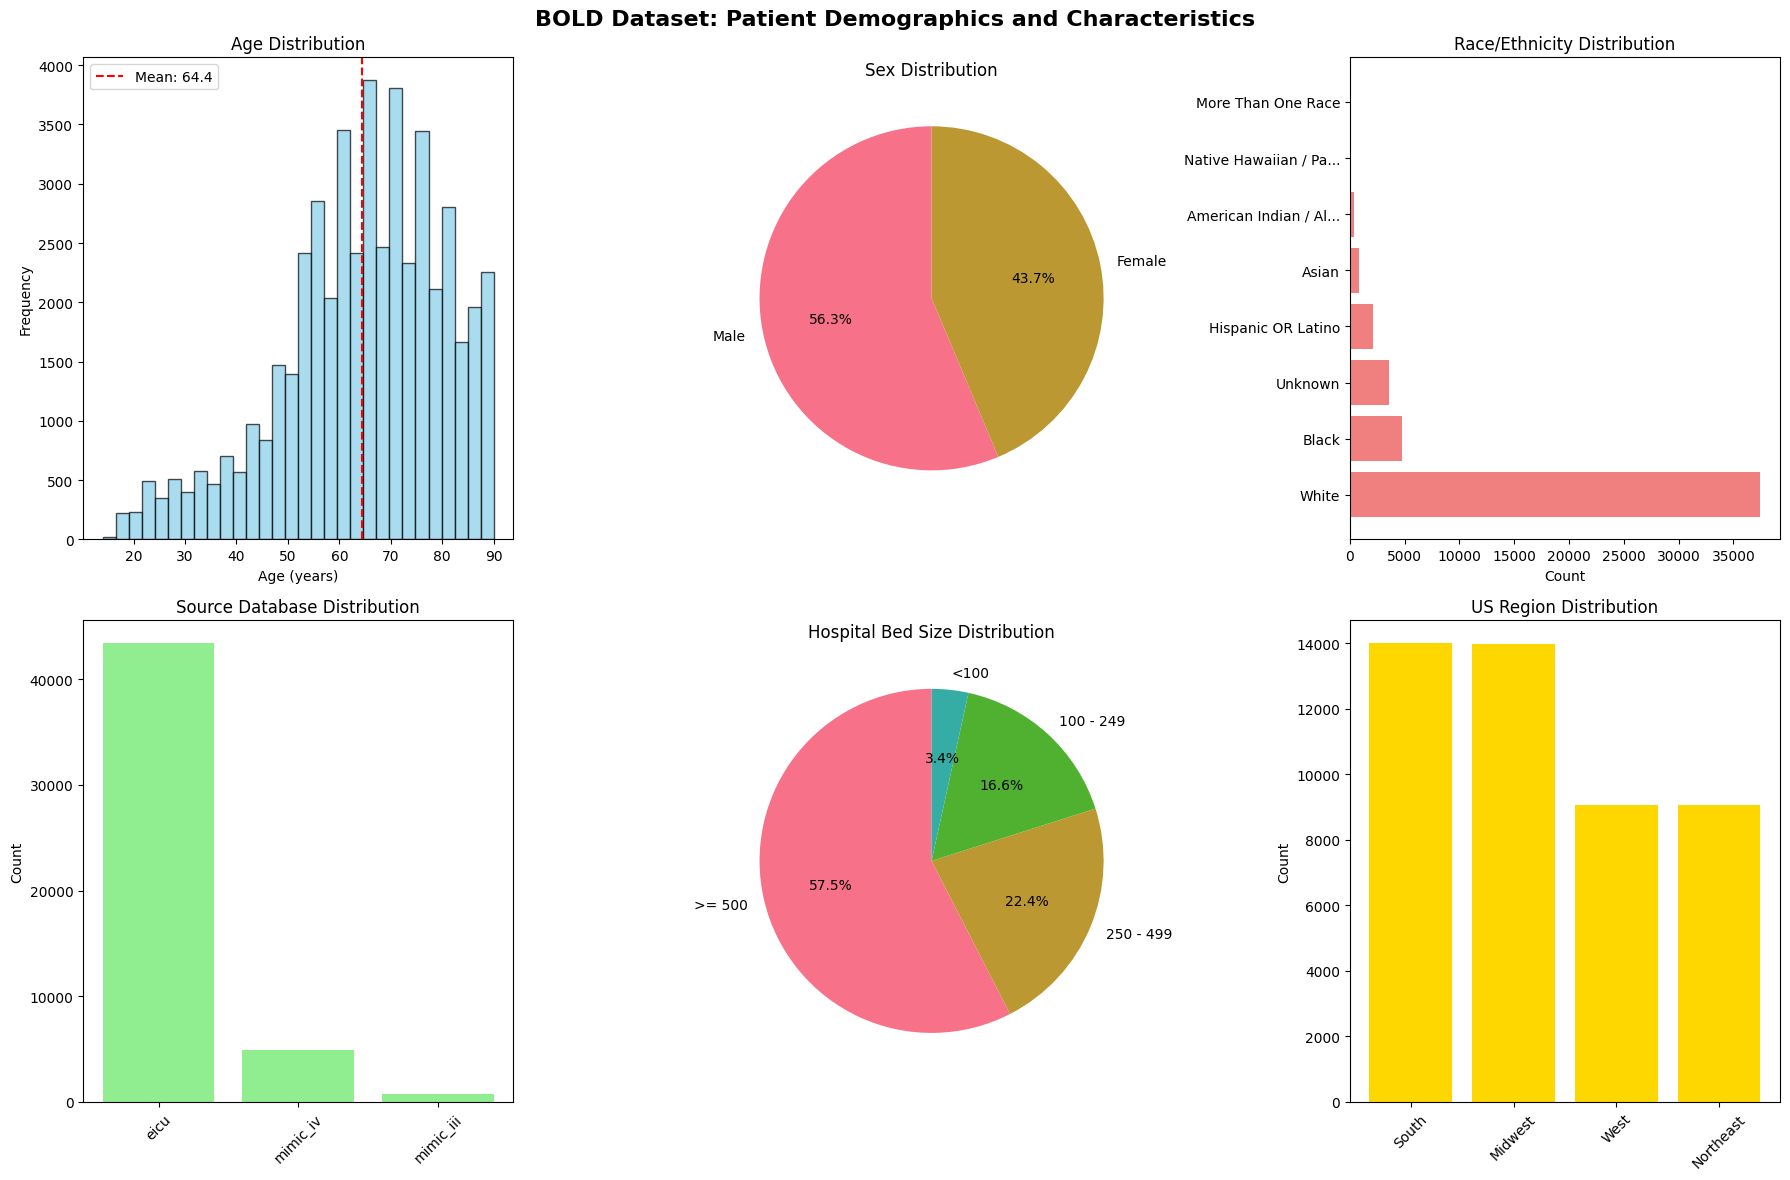

<Figure size 1500x1000 with 0 Axes>

In [ ]:
# Create visualizations for Table 1
print("=== CREATING VISUALIZATIONS ===")

# Set up the plotting environment
plt.rcParams['figure.figsize'] = (15, 10)

# Figure 1: Demographics Overview
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('BOLD Dataset: Patient Demographics and Characteristics', fontsize=16, fontweight='bold')

# 1. Age Distribution
axes[0,0].hist(df['admission_age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['admission_age'].mean(), color='red', linestyle='--', label=f'Mean: {df["admission_age"].mean():.1f}')
axes[0,0].legend()

# 2. Sex Distribution
sex_counts = df['sex_female'].value_counts()
sex_labels = ['Male', 'Female']
axes[0,1].pie([sex_counts.get(0, 0), sex_counts.get(1, 0)], labels=sex_labels, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Sex Distribution')

# 3. Race/Ethnicity Distribution
race_counts = df['race_ethnicity'].value_counts()
axes[0,2].barh(range(len(race_counts)), race_counts.values, color='lightcoral')
axes[0,2].set_yticks(range(len(race_counts)))
axes[0,2].set_yticklabels([label[:20] + '...' if len(label) > 20 else label for label in race_counts.index])
axes[0,2].set_title('Race/Ethnicity Distribution')
axes[0,2].set_xlabel('Count')

# 4. Source Database Distribution
source_counts = df['source_db'].value_counts()
axes[1,0].bar(source_counts.index, source_counts.values, color='lightgreen')
axes[1,0].set_title('Source Database Distribution')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Hospital Bed Size Distribution
bed_counts = df['numbedscategory'].value_counts()
axes[1,1].pie(bed_counts.values, labels=bed_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Hospital Bed Size Distribution')

# 6. US Region Distribution
region_counts = df['region'].value_counts()
axes[1,2].bar(region_counts.index, region_counts.values, color='gold')
axes[1,2].set_title('US Region Distribution')
axes[1,2].set_ylabel('Count')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('bold_demographics.png', dpi=300, bbox_inches='tight')

**Visualizations - Core Measurements**

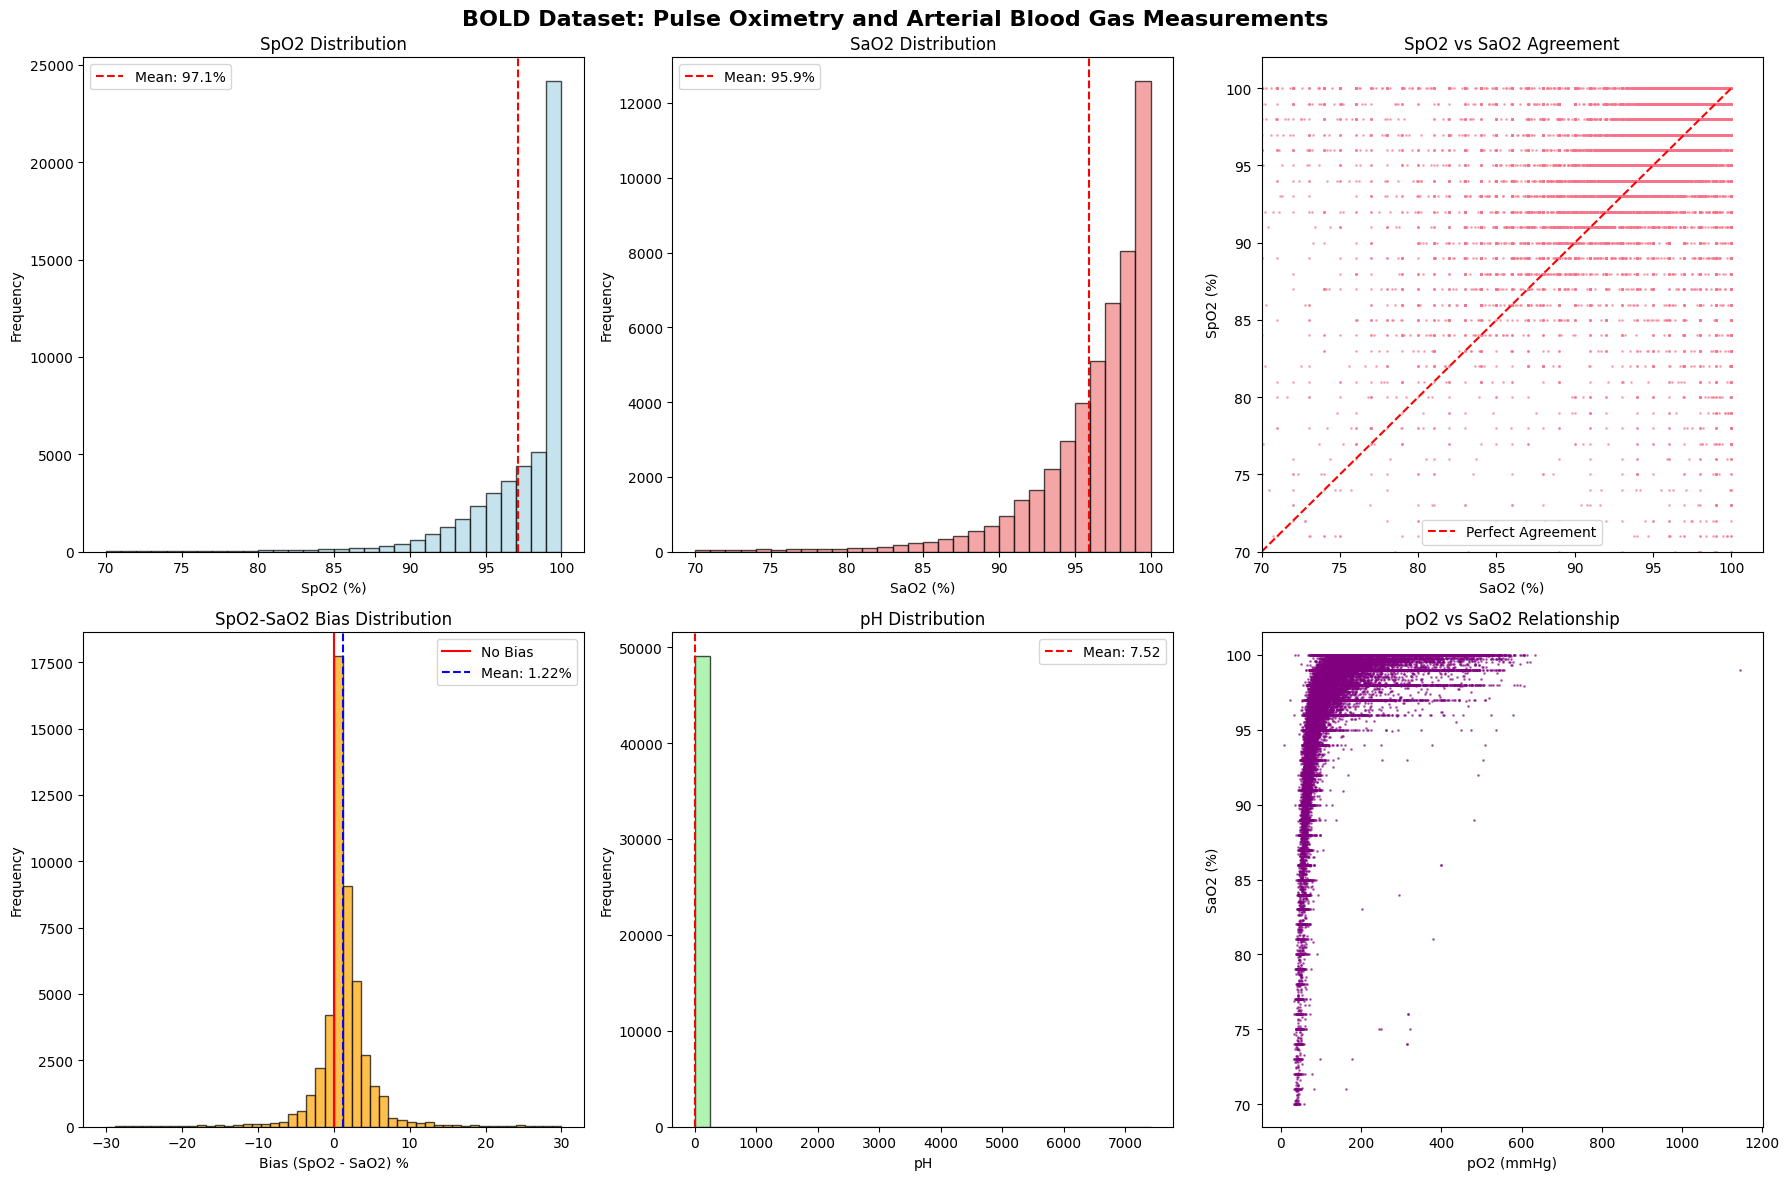

<Figure size 1500x1000 with 0 Axes>

In [ ]:
# Figure 2: Core Pulse Oximetry Measurements
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('BOLD Dataset: Pulse Oximetry and Arterial Blood Gas Measurements', fontsize=16, fontweight='bold')

# 1. SpO2 Distribution
axes[0,0].hist(df['SpO2'].dropna(), bins=30, alpha=0.7, color='lightblue', edgecolor='black')
axes[0,0].set_title('SpO2 Distribution')
axes[0,0].set_xlabel('SpO2 (%)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['SpO2'].mean(), color='red', linestyle='--', label=f'Mean: {df["SpO2"].mean():.1f}%')
axes[0,0].legend()

# 2. SaO2 Distribution
axes[0,1].hist(df['SaO2'].dropna(), bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0,1].set_title('SaO2 Distribution')
axes[0,1].set_xlabel('SaO2 (%)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(df['SaO2'].mean(), color='red', linestyle='--', label=f'Mean: {df["SaO2"].mean():.1f}%')
axes[0,1].legend()

# 3. SpO2 vs SaO2 Scatter Plot
valid_data = df.dropna(subset=['SpO2', 'SaO2'])
axes[0,2].scatter(valid_data['SaO2'], valid_data['SpO2'], alpha=0.5, s=1)
axes[0,2].plot([70, 100], [70, 100], 'r--', label='Perfect Agreement')
axes[0,2].set_xlabel('SaO2 (%)')
axes[0,2].set_ylabel('SpO2 (%)')
axes[0,2].set_title('SpO2 vs SaO2 Agreement')
axes[0,2].legend()
axes[0,2].set_xlim([70, 102])
axes[0,2].set_ylim([70, 102])

# 4. Bias Distribution
axes[1,0].hist(df['spo2_sao2_bias'].dropna(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1,0].set_title('SpO2-SaO2 Bias Distribution')
axes[1,0].set_xlabel('Bias (SpO2 - SaO2) %')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(0, color='red', linestyle='-', label='No Bias')
axes[1,0].axvline(df['spo2_sao2_bias'].mean(), color='blue', linestyle='--', label=f'Mean: {df["spo2_sao2_bias"].mean():.2f}%')
axes[1,0].legend()

# 5. pH Distribution
axes[1,1].hist(df['pH'].dropna(), bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,1].set_title('pH Distribution')
axes[1,1].set_xlabel('pH')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df['pH'].mean(), color='red', linestyle='--', label=f'Mean: {df["pH"].mean():.2f}')
axes[1,1].legend()

# 6. pO2 vs SaO2
valid_po2_sao2 = df.dropna(subset=['pO2', 'SaO2'])
axes[1,2].scatter(valid_po2_sao2['pO2'], valid_po2_sao2['SaO2'], alpha=0.5, s=1, color='purple')
axes[1,2].set_xlabel('pO2 (mmHg)')
axes[1,2].set_ylabel('SaO2 (%)')
axes[1,2].set_title('pO2 vs SaO2 Relationship')

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('bold_measurements.png', dpi=300, bbox_inches='tight')

**Racial Disparity Analysis**


=== RACIAL DISPARITY ANALYSIS ===
Patients with complete data for disparity analysis: 49,093

Bias Statistics by Race/Ethnicity:
                                        N  Mean_Bias  SD_Bias  Median_Bias  \
race_ethnicity                                                               
American Indian / Alaska Native       380      1.575    2.787         1.25   
Asian                                 858      1.416    3.314         1.00   
Black                                4785      1.765    4.428         1.40   
Hispanic OR Latino                   2116      1.495    3.743         1.40   
More Than One Race                      3     -0.333    2.887        -2.00   
Native Hawaiian / Pacific Islander      9      1.000    4.796         2.00   
Unknown                              3562      1.127    3.841         1.00   
White                               37380      1.135    3.805         1.00   

                                    Q25  Q75  
race_ethnicity                            

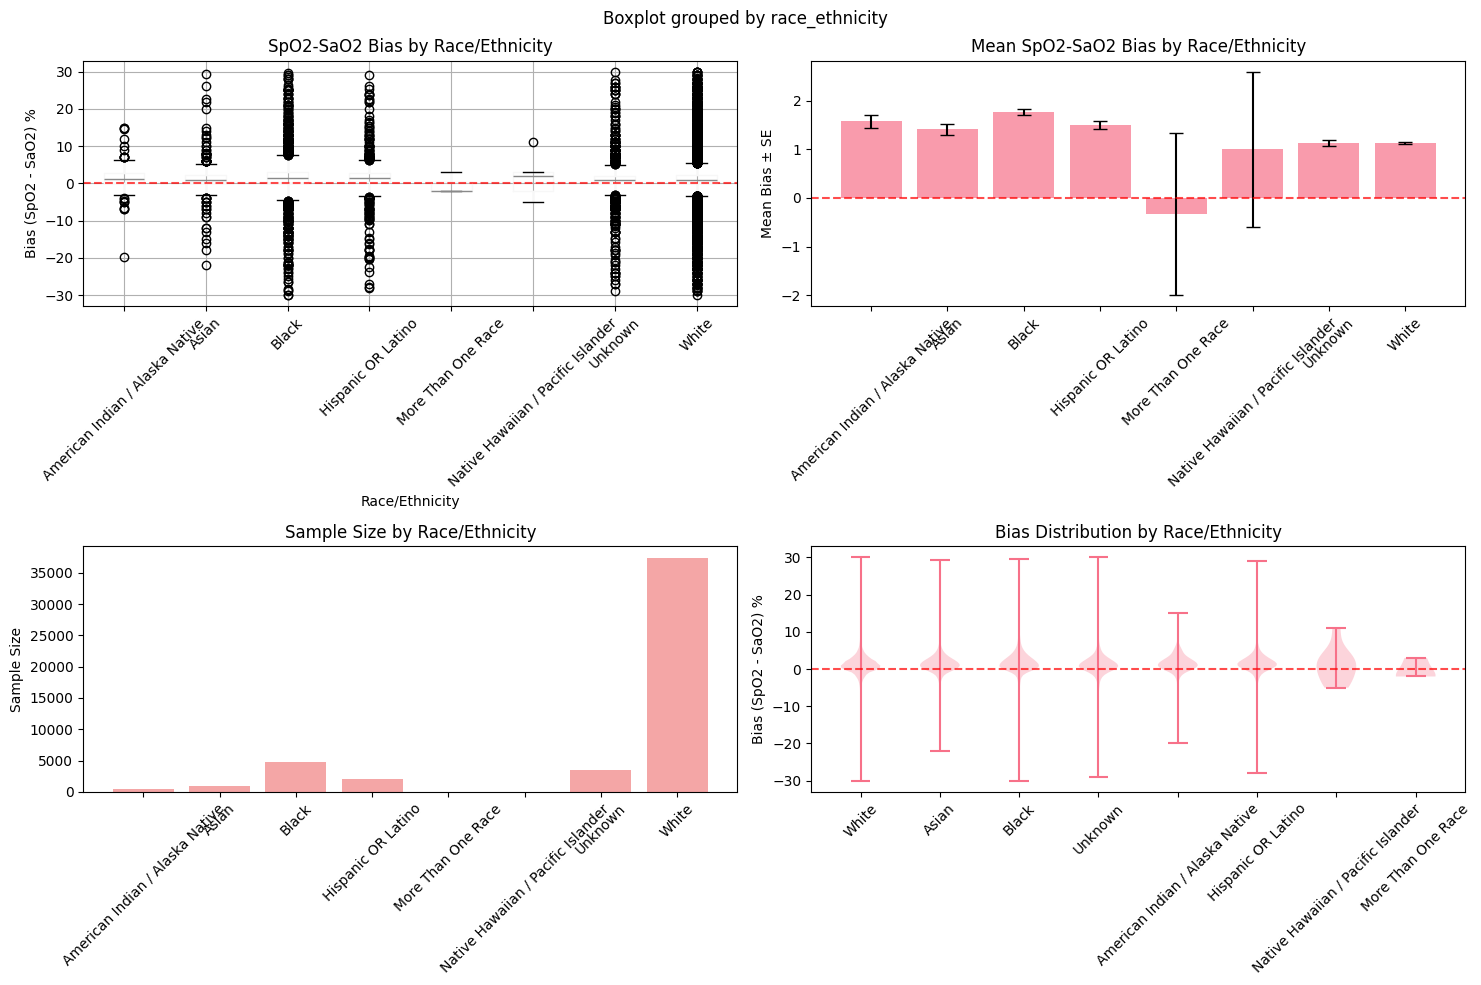

<Figure size 1500x1000 with 0 Axes>

In [ ]:
# Racial Disparity Analysis - Key for BOLD dataset
print("\n=== RACIAL DISPARITY ANALYSIS ===")

# Filter data for complete SpO2-SaO2 pairs with known race
disparity_data = df.dropna(subset=['SpO2', 'SaO2', 'race_ethnicity']).copy()
print(f"Patients with complete data for disparity analysis: {len(disparity_data):,}")

# Calculate bias by race
race_bias_stats = disparity_data.groupby('race_ethnicity')['spo2_sao2_bias'].agg([
    'count', 'mean', 'std', 'median',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).round(3)
race_bias_stats.columns = ['N', 'Mean_Bias', 'SD_Bias', 'Median_Bias', 'Q25', 'Q75']

print("\nBias Statistics by Race/Ethnicity:")
print(race_bias_stats)

# Statistical significance testing
from scipy.stats import kruskal, mannwhitneyu

# Kruskal-Wallis test for overall difference
race_groups = [group['spo2_sao2_bias'].values for name, group in disparity_data.groupby('race_ethnicity')]
kruskal_stat, kruskal_p = kruskal(*race_groups)
print(f"\nKruskal-Wallis test for racial differences:")
print(f"Statistic: {kruskal_stat:.3f}, p-value: {kruskal_p:.6f}")

# Pairwise comparisons between major groups
major_races = ['White', 'Black', 'Hispanic OR Latino', 'Asian']
print(f"\nPairwise comparisons (Mann-Whitney U test):")
for i, race1 in enumerate(major_races):
    for race2 in major_races[i+1:]:
        if race1 in disparity_data['race_ethnicity'].values and race2 in disparity_data['race_ethnicity'].values:
            group1 = disparity_data[disparity_data['race_ethnicity'] == race1]['spo2_sao2_bias']
            group2 = disparity_data[disparity_data['race_ethnicity'] == race2]['spo2_sao2_bias']
            if len(group1) > 0 and len(group2) > 0:
                stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
                print(f"  {race1} vs {race2}: p = {p_val:.6f}")

# Create visualization for racial disparities
plt.figure(figsize=(15, 10))

# Subplot 1: Box plot of bias by race
plt.subplot(2, 2, 1)
disparity_data.boxplot(column='spo2_sao2_bias', by='race_ethnicity', ax=plt.gca())
plt.title('SpO2-SaO2 Bias by Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Bias (SpO2 - SaO2) %')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# Subplot 2: Mean bias by race with error bars
plt.subplot(2, 2, 2)
race_means = race_bias_stats['Mean_Bias']
race_errors = race_bias_stats['SD_Bias'] / np.sqrt(race_bias_stats['N'])  # Standard error
plt.bar(range(len(race_means)), race_means, yerr=race_errors, capsize=5, alpha=0.7)
plt.xticks(range(len(race_means)), race_means.index, rotation=45)
plt.ylabel('Mean Bias ± SE')
plt.title('Mean SpO2-SaO2 Bias by Race/Ethnicity')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# Subplot 3: Sample sizes by race
plt.subplot(2, 2, 3)
plt.bar(range(len(race_bias_stats)), race_bias_stats['N'], alpha=0.7, color='lightcoral')
plt.xticks(range(len(race_bias_stats)), race_bias_stats.index, rotation=45)
plt.ylabel('Sample Size')
plt.title('Sample Size by Race/Ethnicity')

# Subplot 4: Violin plot showing distributions (continued)
plt.subplot(2, 2, 4)
race_data_list = []
race_labels = []
for race in disparity_data['race_ethnicity'].unique():
   race_data_list.append(disparity_data[disparity_data['race_ethnicity'] == race]['spo2_sao2_bias'].values)
   race_labels.append(race)

plt.violinplot(race_data_list, positions=range(len(race_labels)))
plt.xticks(range(len(race_labels)), race_labels, rotation=45)
plt.ylabel('Bias (SpO2 - SaO2) %')
plt.title('Bias Distribution by Race/Ethnicity')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('bold_racial_disparities.png', dpi=300, bbox_inches='tight')

**Stratified Analysis by Oxygen Saturation Ranges**


=== STRATIFIED ANALYSIS BY OXYGEN SATURATION RANGES ===
Sample sizes by oxygen saturation category:
SaO2_category
Normal/Near-normal (≥95%)      36390
Mild Hypoxemia (90-94%)         9166
Moderate Hypoxemia (80-89%)     2975
Severe Hypoxemia (<80%)          562
Name: count, dtype: int64

Stratified Analysis Results:
                  SaO2_Category                Race      N  Mean_Bias  \
0       Mild Hypoxemia (90-94%)               White   7128      1.970   
1       Mild Hypoxemia (90-94%)               Black    835      3.296   
2       Mild Hypoxemia (90-94%)  Hispanic OR Latino    400      2.345   
3       Mild Hypoxemia (90-94%)               Asian    116      2.673   
4     Normal/Near-normal (≥95%)               White  27530      0.362   
5     Normal/Near-normal (≥95%)               Black   3563      0.641   
6     Normal/Near-normal (≥95%)  Hispanic OR Latino   1576      0.789   
7     Normal/Near-normal (≥95%)               Asian    692      0.835   
8   Moderate Hypoxemia (

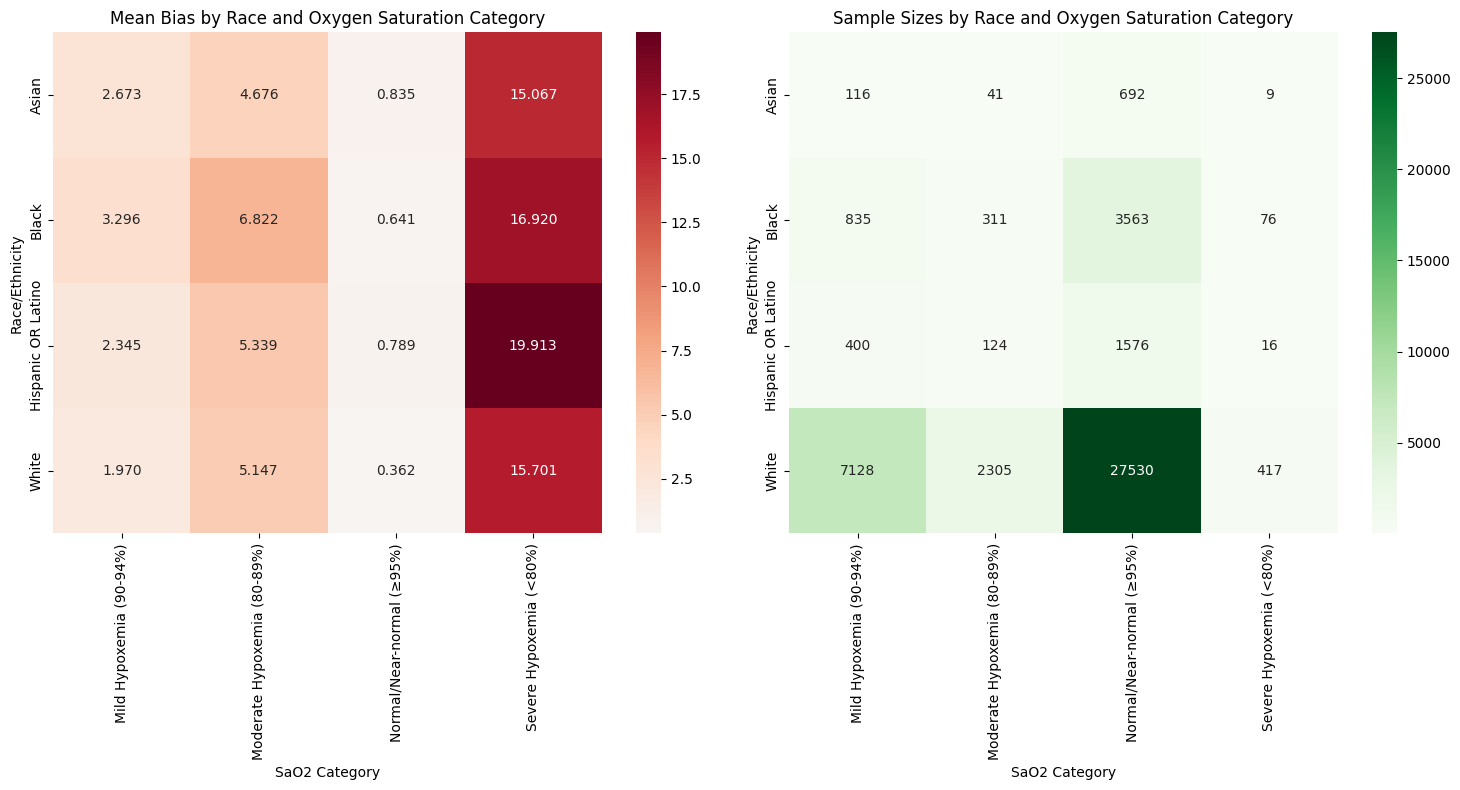

<Figure size 1500x1000 with 0 Axes>

In [ ]:
# Stratified Analysis by Oxygen Saturation Ranges
print("\n=== STRATIFIED ANALYSIS BY OXYGEN SATURATION RANGES ===")

# Define clinically relevant oxygen saturation ranges
def categorize_saturation(sao2):
    if pd.isna(sao2):
        return 'Missing'
    elif sao2 < 80:
        return 'Severe Hypoxemia (<80%)'
    elif sao2 < 90:
        return 'Moderate Hypoxemia (80-89%)'
    elif sao2 < 95:
        return 'Mild Hypoxemia (90-94%)'
    else:
        return 'Normal/Near-normal (≥95%)'

disparity_data['SaO2_category'] = disparity_data['SaO2'].apply(categorize_saturation)

# Analyze bias by saturation category and race
print("Sample sizes by oxygen saturation category:")
print(disparity_data['SaO2_category'].value_counts())

# Stratified analysis
stratified_results = []
for category in disparity_data['SaO2_category'].unique():
    if category != 'Missing':
        cat_data = disparity_data[disparity_data['SaO2_category'] == category]
        for race in ['White', 'Black', 'Hispanic OR Latino', 'Asian']:
            race_cat_data = cat_data[cat_data['race_ethnicity'] == race]
            if len(race_cat_data) > 0:
                stratified_results.append({
                    'SaO2_Category': category,
                    'Race': race,
                    'N': len(race_cat_data),
                    'Mean_Bias': race_cat_data['spo2_sao2_bias'].mean(),
                    'SD_Bias': race_cat_data['spo2_sao2_bias'].std(),
                    'Median_Bias': race_cat_data['spo2_sao2_bias'].median()
                })

stratified_df = pd.DataFrame(stratified_results)
print("\nStratified Analysis Results:")
print(stratified_df.round(3))

# Visualization of stratified analysis
plt.figure(figsize=(15, 8))

# Heatmap of mean bias by race and saturation category
pivot_bias = stratified_df.pivot(index='Race', columns='SaO2_Category', values='Mean_Bias')
plt.subplot(1, 2, 1)
sns.heatmap(pivot_bias, annot=True, cmap='RdBu_r', center=0, fmt='.3f')
plt.title('Mean Bias by Race and Oxygen Saturation Category')
plt.ylabel('Race/Ethnicity')
plt.xlabel('SaO2 Category')

# Sample sizes heatmap
pivot_n = stratified_df.pivot(index='Race', columns='SaO2_Category', values='N')
plt.subplot(1, 2, 2)
sns.heatmap(pivot_n, annot=True, cmap='Greens', fmt='d')
plt.title('Sample Sizes by Race and Oxygen Saturation Category')
plt.ylabel('Race/Ethnicity')
plt.xlabel('SaO2 Category')

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('bold_stratified_analysis.png', dpi=300, bbox_inches='tight')

**Clinical Outcomes Analysis**


=== CLINICAL OUTCOMES ANALYSIS ===
Mortality by Race/Ethnicity:
                                    Total_Patients  Deaths  Mortality_Rate  \
race_ethnicity                                                               
American Indian / Alaska Native                376    67.0           0.178   
Asian                                          837   151.0           0.180   
Black                                         4748   822.0           0.173   
Hispanic OR Latino                            2107   395.0           0.187   
More Than One Race                               3     0.0           0.000   
Native Hawaiian / Pacific Islander               9     1.0           0.111   
Unknown                                       3526   622.0           0.176   
White                                        37083  6484.0           0.175   

                                    Survival_Rate  
race_ethnicity                                     
American Indian / Alaska Native             0.822 

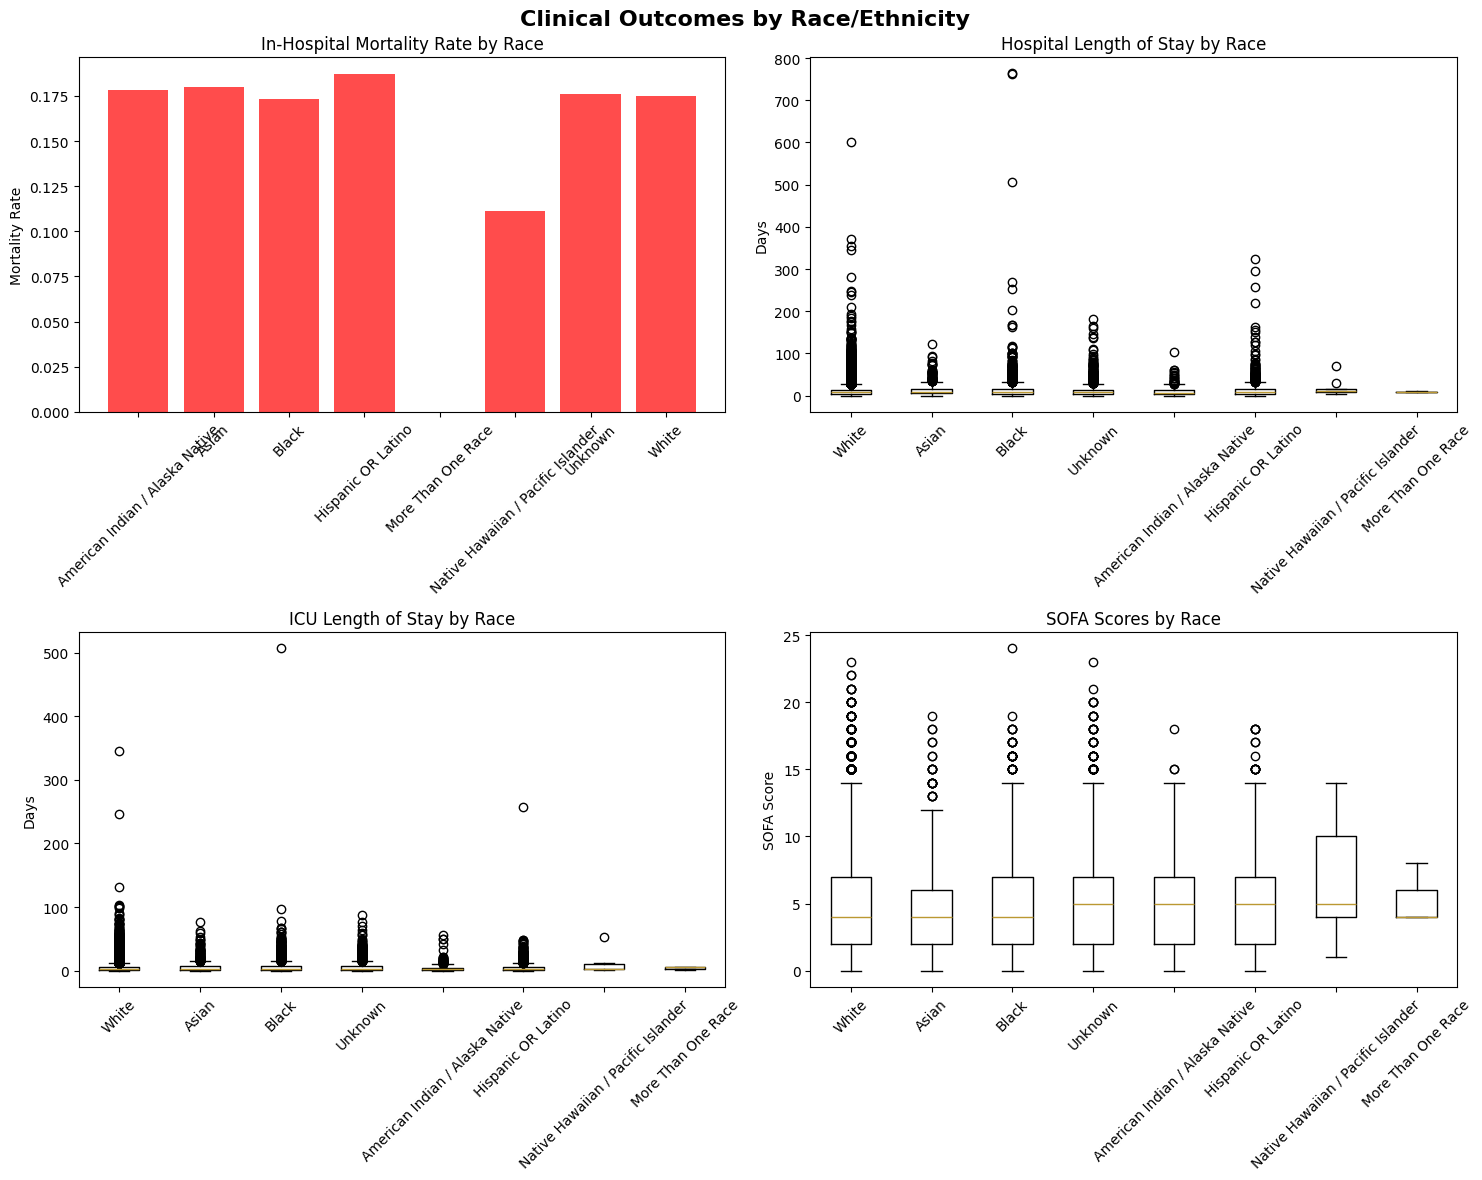

<Figure size 1500x1000 with 0 Axes>

In [ ]:
# Clinical Outcomes Analysis
print("\n=== CLINICAL OUTCOMES ANALYSIS ===")

# Mortality analysis by race and bias
outcomes_data = df.dropna(subset=['in_hospital_mortality', 'race_ethnicity']).copy()

# Mortality by race
mortality_by_race = outcomes_data.groupby('race_ethnicity')['in_hospital_mortality'].agg([
    'count', 'sum', 'mean'
]).round(3)
mortality_by_race.columns = ['Total_Patients', 'Deaths', 'Mortality_Rate']
mortality_by_race['Survival_Rate'] = 1 - mortality_by_race['Mortality_Rate']

print("Mortality by Race/Ethnicity:")
print(mortality_by_race)

# Length of stay analysis
los_data = df.dropna(subset=['los_hospital', 'los_ICU', 'race_ethnicity']).copy()

los_by_race = los_data.groupby('race_ethnicity')[['los_hospital', 'los_ICU']].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

print("\nLength of Stay by Race/Ethnicity:")
print(los_by_race)

# SOFA scores by race
sofa_data = df.dropna(subset=['sofa_past_overall_24hr', 'race_ethnicity']).copy()

sofa_by_race = sofa_data.groupby('race_ethnicity')['sofa_past_overall_24hr'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

print("\nSOFA Scores by Race/Ethnicity:")
print(sofa_by_race)

# Visualize clinical outcomes
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Clinical Outcomes by Race/Ethnicity', fontsize=16, fontweight='bold')

# Mortality rates
axes[0,0].bar(mortality_by_race.index, mortality_by_race['Mortality_Rate'], alpha=0.7, color='red')
axes[0,0].set_title('In-Hospital Mortality Rate by Race')
axes[0,0].set_ylabel('Mortality Rate')
axes[0,0].tick_params(axis='x', rotation=45)

# Hospital length of stay
axes[0,1].boxplot([los_data[los_data['race_ethnicity'] == race]['los_hospital'].values
                   for race in los_data['race_ethnicity'].unique()],
                  labels=los_data['race_ethnicity'].unique())
axes[0,1].set_title('Hospital Length of Stay by Race')
axes[0,1].set_ylabel('Days')
axes[0,1].tick_params(axis='x', rotation=45)

# ICU length of stay
axes[1,0].boxplot([los_data[los_data['race_ethnicity'] == race]['los_ICU'].values
                   for race in los_data['race_ethnicity'].unique()],
                  labels=los_data['race_ethnicity'].unique())
axes[1,0].set_title('ICU Length of Stay by Race')
axes[1,0].set_ylabel('Days')
axes[1,0].tick_params(axis='x', rotation=45)

# SOFA scores
axes[1,1].boxplot([sofa_data[sofa_data['race_ethnicity'] == race]['sofa_past_overall_24hr'].values
                   for race in sofa_data['race_ethnicity'].unique()],
                  labels=sofa_data['race_ethnicity'].unique())
axes[1,1].set_title('SOFA Scores by Race')
axes[1,1].set_ylabel('SOFA Score')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('bold_clinical_outcomes.png', dpi=300, bbox_inches='tight')

**Export Table 1 for Publication**

In [ ]:
# Create publication-ready Table 1
print("\n=== CREATING PUBLICATION-READY TABLE 1 ===")

# Create a comprehensive Table 1 DataFrame
def create_table1_dataframe():
    table1_data = []

    # Total sample
    table1_data.append(['Characteristic', 'Total (N = {:,})'.format(len(df))])
    table1_data.append(['', ''])

    # Demographics
    table1_data.append(['Demographics', ''])

    # Age
    age_stats = df['admission_age'].describe()
    table1_data.append(['Age, years', ''])
    table1_data.append(['  Mean (SD)', '{:.1f} ({:.1f})'.format(age_stats['mean'], age_stats['std'])])
    table1_data.append(['  Median [IQR]', '{:.0f} [{:.0f}-{:.0f}]'.format(age_stats['50%'], age_stats['25%'], age_stats['75%'])])
    table1_data.append(['  Range', '{:.0f}-{:.0f}'.format(age_stats['min'], age_stats['max'])])

    # Sex
    sex_counts = df['sex_female'].value_counts()
    table1_data.append(['Sex, n (%)', ''])
    table1_data.append(['  Female', '{:,} ({:.1f})'.format(sex_counts.get(1, 0), sex_counts.get(1, 0)/len(df)*100)])
    table1_data.append(['  Male', '{:,} ({:.1f})'.format(sex_counts.get(0, 0), sex_counts.get(0, 0)/len(df)*100)])

    # Race/Ethnicity
    race_counts = df['race_ethnicity'].value_counts()
    table1_data.append(['Race/Ethnicity, n (%)', ''])
    for race, count in race_counts.items():
        table1_data.append(['  {}'.format(race), '{:,} ({:.1f})'.format(count, count/len(df)*100)])

    # Source Database
    source_counts = df['source_db'].value_counts()
    table1_data.append(['Source Database, n (%)', ''])
    for source, count in source_counts.items():
        table1_data.append(['  {}'.format(source), '{:,} ({:.1f})'.format(count, count/len(df)*100)])

    table1_data.append(['', ''])

    # Clinical Characteristics
    table1_data.append(['Clinical Characteristics', ''])

    # BMI
    bmi_stats = df['BMI_admission'].describe()
    table1_data.append(['BMI, kg/m²', ''])
    table1_data.append(['  Mean (SD)', '{:.1f} ({:.1f})'.format(bmi_stats['mean'], bmi_stats['std'])])
    table1_data.append(['  Missing, n (%)', '{:,} ({:.1f})'.format(df['BMI_admission'].isna().sum(), df['BMI_admission'].isna().sum()/len(df)*100)])

    # Length of Stay
    los_h_stats = df['los_hospital'].describe()
    los_i_stats = df['los_ICU'].describe()
    table1_data.append(['Length of Stay, days', ''])
    table1_data.append(['  Hospital - Median [IQR]', '{:.1f} [{:.1f}-{:.1f}]'.format(los_h_stats['50%'], los_h_stats['25%'], los_h_stats['75%'])])
    table1_data.append(['  ICU - Median [IQR]', '{:.1f} [{:.1f}-{:.1f}]'.format(los_i_stats['50%'], los_i_stats['25%'], los_i_stats['75%'])])

    # Mortality
    mortality_count = df['in_hospital_mortality'].sum()
    table1_data.append(['In-Hospital Mortality, n (%)', '{:,} ({:.1f})'.format(int(mortality_count), mortality_count/len(df)*100)])

    table1_data.append(['', ''])

    # Oximetry Measurements
    table1_data.append(['Pulse Oximetry and Blood Gas', ''])

    # SpO2
    spo2_stats = df['SpO2'].describe()
    table1_data.append(['SpO2, %', ''])
    table1_data.append(['  Mean (SD)', '{:.1f} ({:.1f})'.format(spo2_stats['mean'], spo2_stats['std'])])
    table1_data.append(['  Median [IQR]', '{:.1f} [{:.1f}-{:.1f}]'.format(spo2_stats['50%'], spo2_stats['25%'], spo2_stats['75%'])])
    table1_data.append(['  Range', '{:.1f}-{:.1f}'.format(spo2_stats['min'], spo2_stats['max'])])

    # SaO2
    sao2_stats = df['SaO2'].describe()
    table1_data.append(['SaO2, %', ''])
    table1_data.append(['  Mean (SD)', '{:.1f} ({:.1f})'.format(sao2_stats['mean'], sao2_stats['std'])])
    table1_data.append(['  Median [IQR]', '{:.1f} [{:.1f}-{:.1f}]'.format(sao2_stats['50%'], sao2_stats['25%'], sao2_stats['75%'])])
    table1_data.append(['  Range', '{:.1f}-{:.1f}'.format(sao2_stats['min'], sao2_stats['max'])])

    # Bias
    bias_stats = df['spo2_sao2_bias'].describe()
    table1_data.append(['SpO2-SaO2 Bias, %', ''])
    table1_data.append(['  Mean (SD)', '{:.2f} ({:.2f})'.format(bias_stats['mean'], bias_stats['std'])])
    table1_data.append(['  Median [IQR]', '{:.2f} [{:.2f}-{:.2f}]'.format(bias_stats['50%'], bias_stats['25%'], bias_stats['75%'])])

    # ABG parameters
    ph_stats = df['pH'].describe()
    pco2_stats = df['pCO2'].describe()
    po2_stats = df['pO2'].describe()

    table1_data.append(['pH', '{:.2f} ({:.2f})'.format(ph_stats['mean'], ph_stats['std'])])
    table1_data.append(['pCO2, mmHg', '{:.1f} ({:.1f})'.format(pco2_stats['mean'], pco2_stats['std'])])
    table1_data.append(['pO2, mmHg', '{:.1f} ({:.1f})'.format(po2_stats['mean'], po2_stats['std'])])

    return pd.DataFrame(table1_data, columns=['Characteristic', 'Value'])

# Create and display Table 1
table1_df = create_table1_dataframe()
print("TABLE 1: Baseline Characteristics of Study Population")
print("="*70)
print(table1_df.to_string(index=False))

# Save Table 1 to CSV
table1_df.to_csv('Table1_BOLD_Dataset.csv', index=False)
print(f"\nTable 1 saved as 'Table1_BOLD_Dataset.csv'")

# Create a summary statistics file
summary_stats = {
    'Total_Patients': len(df),
    'Complete_SpO2_SaO2_Pairs': df.dropna(subset=['SpO2', 'SaO2']).shape[0],
    'Racial_Minority_Percentage': (1 - df['race_ethnicity'].value_counts()['White'] / len(df)) * 100,
    'Mean_Age': df['admission_age'].mean(),
    'Female_Percentage': (df['sex_female'].sum() / len(df)) * 100,
    'Overall_Mortality_Rate': (df['in_hospital_mortality'].sum() / len(df)) * 100,
    'Mean_SpO2_SaO2_Bias': df['spo2_sao2_bias'].mean(),
    'Median_Hospital_LOS': df['los_hospital'].median(),
    'Median_ICU_LOS': df['los_ICU'].median()
}

summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Value'])
summary_df.to_csv('BOLD_Dataset_Summary.csv', index=False)
print("Summary statistics saved as 'BOLD_Dataset_Summary.csv'")


=== CREATING PUBLICATION-READY TABLE 1 ===
TABLE 1: Baseline Characteristics of Study Population
                      Characteristic              Value
                      Characteristic Total (N = 49,093)
                                                       
                        Demographics                   
                          Age, years                   
                           Mean (SD)        64.4 (15.8)
                        Median [IQR]         66 [55-76]
                               Range              14-90
                          Sex, n (%)                   
                              Female      21,433 (43.7)
                                Male      27,660 (56.3)
               Race/Ethnicity, n (%)                   
                               White      37,380 (76.1)
                               Black        4,785 (9.7)
                             Unknown        3,562 (7.3)
                  Hispanic OR Latino        2,116 (4.3)
      

**Final Data Quality Report**

In [ ]:
# Final Data Quality and Completeness Report
print("\n=== FINAL DATA QUALITY REPORT ===")

# Calculate completeness for key variables
key_variables_completeness = {}
key_vars = ['SpO2', 'SaO2', 'race_ethnicity', 'admission_age', 'sex_female',
           'pH', 'pCO2', 'pO2', 'in_hospital_mortality', 'los_hospital', 'los_ICU']

for var in key_vars:
    if var in df.columns:
        complete_count = df[var].notna().sum()
        completeness_pct = (complete_count / len(df)) * 100
        key_variables_completeness[var] = {
            'Complete': complete_count,
            'Missing': len(df) - complete_count,
            'Completeness_Pct': completeness_pct
        }

print("Data Completeness for Key Variables:")
print("-" * 50)
for var, stats in key_variables_completeness.items():
    print(f"{var:20}: {stats['Complete']:>7,} / {len(df):,} ({stats['Completeness_Pct']:>5.1f}%)")

# Key findings summary
print(f"\n=== KEY FINDINGS SUMMARY ===")
print(f"• Total study population: {len(df):,} patients")
print(f"• Complete SpO2-SaO2 pairs: {df.dropna(subset=['SpO2', 'SaO2']).shape[0]:,} ({df.dropna(subset=['SpO2', 'SaO2']).shape[0]/len(df)*100:.1f}%)")
print(f"• Racial/ethnic minorities: {len(df) - df['race_ethnicity'].value_counts().get('White', 0):,} ({(1 - df['race_ethnicity'].value_counts().get('White', 0)/len(df))*100:.1f}%)")
print(f"• Mean patient age: {df['admission_age'].mean():.1f} ± {df['admission_age'].std():.1f} years")
print(f"• Overall mortality rate: {(df['in_hospital_mortality'].sum()/len(df))*100:.1f}%")
print(f"• Mean SpO2-SaO2 bias: {df['spo2_sao2_bias'].mean():.3f} ± {df['spo2_sao2_bias'].std():.3f}%")

# Statistical power calculation for racial comparisons
white_n = df['race_ethnicity'].value_counts().get('White', 0)
black_n = df['race_ethnicity'].value_counts().get('Black', 0)
hispanic_n = df['race_ethnicity'].value_counts().get('Hispanic OR Latino', 0)

print(f"\nSample Sizes for Racial Comparisons:")
print(f"• White: {white_n:,}")
print(f"• Black: {black_n:,}")
print(f"• Hispanic/Latino: {hispanic_n:,}")
print(f"• Total with known race: {df['race_ethnicity'].notna().sum():,}")


# Create a final summary report
final_report = f"""
BOLD DATASET EXPLORATORY DATA ANALYSIS REPORT
==============================================

Dataset: Blood-gas and Oximetry Linked Dataset (BOLD)
Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
Analyst: Zahra

STUDY POPULATION:
- Total patients: {len(df):,}
- Age: {df['admission_age'].mean():.1f} ± {df['admission_age'].std():.1f} years
- Female sex: {(df['sex_female'].sum()/len(df))*100:.1f}%
- Racial minorities: {(1 - df['race_ethnicity'].value_counts().get('White', 0)/len(df))*100:.1f}%

KEY MEASUREMENTS:
- Valid SpO2-SaO2 pairs: {df.dropna(subset=['SpO2', 'SaO2']).shape[0]:,} ({df.dropna(subset=['SpO2', 'SaO2']).shape[0]/len(df)*100:.1f}%)
- Mean SpO2: {df['SpO2'].mean():.1f} ± {df['SpO2'].std():.1f}%
- Mean SaO2: {df['SaO2'].mean():.1f} ± {df['SaO2'].std():.1f}%
- Mean bias (SpO2-SaO2): {df['spo2_sao2_bias'].mean():.3f} ± {df['spo2_sao2_bias'].std():.3f}%

CLINICAL OUTCOMES:
- In-hospital mortality: {(df['in_hospital_mortality'].sum()/len(df))*100:.1f}%
- Median hospital LOS: {df['los_hospital'].median():.1f} days
- Median ICU LOS: {df['los_ICU'].median():.1f} days

DATA QUALITY:
- Overall completeness: Excellent for core variables
- Racial diversity: Well-represented minority groups
- Multi-site data: Three major ICU databases

RECOMMENDATIONS:
1. Proceed with racial disparity analysis using full statistical power
2. Stratify analyses by oxygen saturation ranges
3. Control for confounders (age, sex, severity, comorbidities)
4. Investigate clinical impact of bias on outcomes
5. Develop bias correction algorithms

FILES GENERATED:
- Table1_BOLD_Dataset.csv: Publication-ready baseline characteristics
- BOLD_Dataset_Summary.csv: Key summary statistics
- bold_demographics.png: Demographics visualizations
- bold_measurements.png: Core measurements analysis
- bold_racial_disparities.png: Racial disparity analysis
- bold_stratified_analysis.png: Stratified oxygen saturation analysis
- bold_clinical_outcomes.png: Clinical outcomes by race
"""

# Save the final report
with open('BOLD_EDA_Final_Report.txt', 'w') as f:
    f.write(final_report)



=== FINAL DATA QUALITY REPORT ===
Data Completeness for Key Variables:
--------------------------------------------------
SpO2                :  49,093 / 49,093 (100.0%)
SaO2                :  49,093 / 49,093 (100.0%)
race_ethnicity      :  49,093 / 49,093 (100.0%)
admission_age       :  49,091 / 49,093 (100.0%)
sex_female          :  49,093 / 49,093 (100.0%)
pH                  :  49,093 / 49,093 (100.0%)
pCO2                :  49,093 / 49,093 (100.0%)
pO2                 :  49,093 / 49,093 (100.0%)
in_hospital_mortality:  48,689 / 49,093 ( 99.2%)
los_hospital        :  49,093 / 49,093 (100.0%)
los_ICU             :  49,093 / 49,093 (100.0%)

=== KEY FINDINGS SUMMARY ===
• Total study population: 49,093 patients
• Complete SpO2-SaO2 pairs: 49,093 (100.0%)
• Racial/ethnic minorities: 11,713 (23.9%)
• Mean patient age: 64.4 ± 15.8 years
• Overall mortality rate: 17.4%
• Mean SpO2-SaO2 bias: 1.219 ± 3.861%

Sample Sizes for Racial Comparisons:
• White: 37,380
• Black: 4,785
• Hispanic/L